# 1. Research Question

## Research Question

Can we guess a song's musical genre just from its lyrics?

A country ballad and a hip-hop track feel completely different on the page — but is that intuition backed by measurable linguistic patterns? We frame this as a **multi-class text classification** problem: given only raw lyrics, predict whether a song is Rock, Pop, Hip-Hop, Metal, Country, Jazz, Electronic, Folk, R&B, or Indie.

- **Task:** Multi-class text classification.
- **Input:** Song lyrics (raw text).
- **Target variable:** Musical genre (categorical label).
- **Hypothesis:** Each genre leaves a distinct linguistic fingerprint — in vocabulary, syntax, and rhetoric — strong enough to beat a majority-class baseline.

**Expected observations:** Hip-Hop stands out through slang and self-reference; Country through rural imagery; Metal through aggressive vocabulary. Syntactically, Hip-Hop favors short lines while Folk leans narrative. Models that capture context and word order should outperform simpler bag-of-words approaches.

---

## Required Reflection

### 1. Why is this question non-trivial?

At first glance, guessing genre from lyrics sounds straightforward — but it really isn't, for a few reasons:

- **Genre boundaries are blurry.** A song tagged as Pop-Rock on Spotify doesn't neatly fit either category. Labels are often assigned by platforms or marketing, not by any linguistic criterion.
- **We're throwing away most of the signal.** Without melody, tempo, or instrumentation, the classifier only gets the text. That's a fraction of what actually defines a genre.
- **Huge variation within genres.** A quiet acoustic Rock ballad and an arena Rock anthem share a label but almost nothing else in their lyrics.
- **Class imbalance.** Rock dominates most lyrics datasets, which means the model could learn to just predict "Rock" and still look decent on accuracy.

### 2. What linguistic phenomenon does it involve?

At its core, this project is about **register variation conditioned by genre** — the idea that the social and artistic context of a song shapes how language is used. More concretely, we're looking at:

- **Lexical semantics:** Do genres prefer different words and word distributions?
- **Morpho-syntactic patterns:** Are there measurable differences in POS-tag usage, sentence length, or syntactic complexity across genres?
- **Pragmatics and rhetoric:** Do genres differ in their use of repetition, imperatives, interjections, or figurative language?
- **Sociolinguistic register:** How much do formality, slang density, and code-switching vary from one genre to another?

### 3. What would falsify our hypothesis?

We'd have to admit we were wrong if:

- All models — including the most expressive ones — perform around the majority-class baseline, which would mean lyrics simply don't carry enough genre signal.
- Our linguistic analyses show no statistically significant vocabulary, syntactic, or rhetorical differences across genres.
- Misclassification errors are scattered randomly instead of clustering around genre pairs that are linguistically close (e.g., Rock/Metal, Folk/Country), which would suggest the models aren't really learning meaningful language patterns.

# 2. Data & Preprocessing

## Loading the dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akyshnik/lyrics")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 90.0M/90.0M [00:16<00:00, 5.78MB/s]

Extracting files...


Path to dataset files: /Users/carmo/.cache/kagglehub/datasets/akyshnik/lyrics/versions/1


In [2]:
import os

print(os.listdir(path))

['kaggle_clean.csv']


In [3]:
import pandas as pd

file_path = os.path.join(path, "kaggle_clean.csv")
df = pd.read_csv(file_path)

## 2.1 Dataset Selection

### Checking the values

In [4]:
print(df["genre"].unique())
df.info(),
df.sample(10)

['Pop' 'Hip-Hop' 'Not Available' 'Rock' 'Metal' 'Other' 'Country' 'Jazz'
 'Electronic' 'Folk' 'R&B' 'Indie']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266557 entries, 0 to 266556
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  266557 non-null  int64 
 1   index       266557 non-null  int64 
 2   song        266556 non-null  object
 3   year        266557 non-null  int64 
 4   artist      266557 non-null  object
 5   genre       266557 non-null  object
 6   lyrics      266535 non-null  object
 7   wnum        266557 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 16.3+ MB


,Unnamed: 0,index,song,year,artist,genre,lyrics,wnum
241830,241830,328744,you-can-make-history,2006,elton-john,Rock,i can feel the time closing in\ni can feel the...,208
238026,238026,323020,every-subway-car,2010,barenaked-ladies,Rock,my backpack was faded black\nbut now it's all ...,191
3403,3403,5030,love-letters,2002,billy-thorpe,Rock,love letters straight from your heart\nkeep us...,96
241171,241171,327942,fools-paradise,2006,donna-lewis,Pop,manipulated romance\npretty speeches in the da...,144
180768,180768,246209,i-wanna-be-down,2006,brandy,Pop,i would like to get to know if i could be\nthe...,213
219694,219694,299327,february-stars,2006,foo-fighters,Rock,hangin' on here until i'm gone\nright where i ...,128
76878,76878,107092,hang-on-to-yourself,2007,belle-perez,Pop,when i was a little girl\nmy mama used to say\...,283
21222,21222,29716,i-walk-the-line,2007,bill-anderson,Country,i keep a close watch on this heart of mine i k...,124
66612,66612,92429,where-did-you-go,2006,boney-m,Pop,i'm looking out the window pane\nand i hear th...,279
74509,74509,103715,strange-band,1971,family,Rock,dog and his master took out together\nheading ...,70


In [5]:
print(len(df))
df = df.dropna(subset=["lyrics"])
print(len(df))

266557
266535


### Drop columns with useless information

In [6]:
df = df.drop(columns=["Unnamed: 0", "index"])

### Modify useless values

We modify every value from the lyrics that are formed by one word to be "instrumental"

In [7]:
df.loc[df["wnum"] == 1, "lyrics"].value_counts()

lyrics
instrumental     3645
instru             51
intro              10
instumental        10
intrumental         9
                 ... 
akustisch           1
interlude           1
instrumental}       1
illuminate          1
bonus               1
Name: count, Length: 73, dtype: int64

In [8]:
df.loc[df["wnum"] == 1, "lyrics"] = "instrumental"
df.loc[df["wnum"] == 1, "lyrics"].value_counts()

lyrics
instrumental    3820
Name: count, dtype: int64

### Eliminate Non Available values

We do this because there is enough values to being able to eliminate every row that has incomplete information.

In [9]:
df_clean = df[~df["genre"].isin(["Not Available"])]
df_clean = df_clean[~df_clean["year"].isin([112, 702, 67])]

In [10]:
print(len(df), len(df_clean))

266535 242595


### Check impact of instrumental songs

In [11]:
print("Percentage of instrumental songs for each genre:\n")

inst = df_clean["genre"][df_clean["lyrics"] == "instrumental"].value_counts()
no_inst = df_clean["genre"][df_clean["lyrics"] != "instrumental"].value_counts()
genres = inst.keys()

for i in range(len(inst)):
    print(genres[i]+": ", round((inst.iloc[i]/no_inst.iloc[i])*100, 2), "\b%")

Percentage of instrumental songs for each genre:

Rock:  1.3%
Metal:  1.9%
Electronic:  1.4%
Pop:  0.88%
Jazz:  1.01%
Folk:  1.73%
Hip-Hop:  1.1%
Country:  1.23%
Indie:  1.33%
R&B:  0.32%
Other:  0.28%


### Check number of values of each genre

In [12]:
genre_values = df_clean["genre"].value_counts()
df_size = len(df_clean)
biggest_value = 0
for genre in genres:
    if len(genre) > biggest_value:
        biggest_value = len(genre)
for i in range(len(genres)):
    rounded_number = round((genre_values.iloc[i]/df_size)*100, 2)
    print(genres[i]+":"+" "*(biggest_value-len(genres[i]) + 5-len(str(rounded_number))), 
          rounded_number, "\b%\t", genre_values.iloc[i])

Rock:       45.02%	 109221
Metal:      16.68%	 40465
Electronic: 10.24%	 24844
Pop:         9.79%	 23759
Jazz:        5.93%	 14387
Folk:        3.29%	 7971
Hip-Hop:     3.28%	 7966
Country:     2.14%	 5189
Indie:        1.4%	 3401
R&B:          1.3%	 3149
Other:       0.92%	 2243


### Dataset Description

- Source: https://www.kaggle.com/datasets/akyshnik/lyrics
- Domain: Prediction of music genre from the lyrics.
- Label distribution:
| Genre | Percentage | Samples |
| --- | --- | --- |
| Rock | 54.02% | 109235 |
| Metal | 16.68% | 40465 |
| Electronic | 10.24% | 24845 |
| Pop | 9.79% | 23759 |
| Jazz | 5.93% | 14387 |
| Folk | 3.29% | 7971 |
| Hip-Hop | 3.28% | 7966 |
| Country | 2.14% | 5189 |
| Indie | 1.4% | 3401 |
| R&B | 1.3% | 3149 |
| Other | 0.92% | 2243 |
- Potential biases: The dataset can be biased towards Rock music, since almost half of the music from this dataset is Rock. But, even with this statement, the most represented genres (Rock, Metal, Electronic, Pop) have subgenres inside them (blues rock, goth metal, afro music, pop-punk). So it makes sense for these genres to have the most amount of samples.
- Ethical considerations: All the information of the dataset is public. Some songs contain offensive language, but this shouldn't be taken as harmful content, since offensive language also helps defining a way of expressing, thus helping on the genre prediction.

## 2.2 Data Split

### Data Split justification

For the data split, we will give 70% to the train dataset, 15% to the development dataset, and 15% to the test dataset.
The reason of this division is to train the dataset with the most amount of data, so the model can learn patterns correctly. For this reason, the development and test datasets should be big enough to work properly, but as small as possible to use the most amount of data on the training dataset.

The randomness is controlled via the random_state parameter. By applying a value on this parameter, we ensure that every time we repeat the executions, the dataset will split in the same way.

We also use stratification to keep the label proportions evenly in each dataset, since it wouldn't be ideal to have one of the datasets almost full of Rock songs, for example.

In [13]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(df_clean, test_size=0.3, stratify=df_clean["genre"], random_state=42)
df_dev, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["genre"], random_state=42)

In [14]:
print(len(df_clean), len(df_train), len(df_dev), len(df_test))

242595 169816 36389 36390


## 2.3 Preprocessing strategy

In [15]:
df_train.info()
df_train.sample(10)

<class 'pandas.core.frame.DataFrame'>
Index: 169816 entries, 229632 to 68966
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   song    169815 non-null  object
 1   year    169816 non-null  int64 
 2   artist  169816 non-null  object
 3   genre   169816 non-null  object
 4   lyrics  169816 non-null  object
 5   wnum    169816 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 9.1+ MB


,song,year,artist,genre,lyrics,wnum
81517,for-i-am-his-slave,2007,armagedda,Metal,i don't like the modern humans\ni don't care i...,111
177604,hmm-hmm-album-version,2008,beenie-man,Hip-Hop,zagga! shocking vibes! tony kelly!\nyo! is it ...,481
214094,lovesong,2007,archive,Rock,all this time i'm distracted from the world\nt...,289
72630,my-sub-pt2-the-jackin,2012,big-k-r-i-t,Hip-Hop,my sub my sub my sub i put that on my sub!\nmy...,554
172180,just-as-i-am,2011,fernando-ortega,Pop,i waited and waited for god\nhe turned and he ...,201
115149,she-s-not-innocent,2008,antigone-rising,Rock,he casts a shadow down the block\nhe can't rem...,211
109174,i-am-a-pilgrim,2008,alabama,Rock,i am a pilgrim and a stranger\ntraveling throu...,213
54612,lover-i-don-t-have-to-love,2002,bright-eyes,Rock,i picked you out\nof a crowd and talked to you...,305
67583,refused-by-light,1997,commander-venus,Rock,the light refused us with designed intent\nint...,173
55089,scene-girls,2009,brokencyde,Hip-Hop,if you're a scene girl go back it up\nput your...,324


* tokenization method: word-level tokenization, since the meaning of words are very useful to identify the music genre.
* lemmatization vs stemming: lemmatization, because we want to the actual meaning of words, which is also very useful to identify the music genre.
* stopword removal (or not): we will keep them, since there are genres that don't use many and will be easier to identify.
* rare word filtering: we will take them out, because rare words might increase psarsity.
* handling of emojis / punctuation: there are no emojis. We will keep the punctuation in case we use transformers.
* subword tokenization (if transformer): we will use a pre-trained transformer, such as BERT.

In [16]:
# Unique words (Vocabulary Size)
# We convert to lowercase to avoid counting "The" and "the" as different words
initial_vocab = set()
df_train['lyrics'].str.lower().str.split().apply(initial_vocab.update)

# Average Words per Song
# split() counts every word separated by whitespace
avg_words_before = df_train['lyrics'].apply(lambda x: len(x.split())).mean()

print(f"Vocab Size Before: {len(initial_vocab)}")
print(f"Avg Words per Song Before: {avg_words_before:.2f}")

Vocab Size Before: 453369
Avg Words per Song Before: 228.45


### Preprocessing application

In [17]:
import re
from collections import Counter

# 1. Define a standard tokenization function (as per teacher's guide)
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

# 2. Applying tokenization to the dataset
df_train['tokens'] = df_train['lyrics'].apply(tokenize)

# 3. Handling Stopwords
with open('EN-Stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip().lower() for line in f if line.strip())
df_train['tokens'] = df_train['tokens'].apply(lambda x: [t for t in x if t not in stopwords])

# 4. Rare Word Filtering
vocab_counter = Counter()
df_train['tokens'].apply(vocab_counter.update)

# We identify words that appear fewer than 5 times
min_freq = 5
rare_words = {word for word, count in vocab_counter.items() if count < min_freq}

# Filtering of rare words
df_train['tokens'] = df_train['tokens'].apply(lambda x: [t for t in x if t not in rare_words])

In [18]:
from collections import Counter

# 1. Vocabulary Size After
final_vocab = Counter()
df_train['tokens'].apply(final_vocab.update)

# 2. Average Tokens per Song After
avg_tokens_after = df_train['tokens'].apply(len).mean()

print(f"Vocab Size After: {len(final_vocab)}")
print(f"Avg Tokens per Song After: {avg_tokens_after:.2f}")

Vocab Size After: 87004
Avg Tokens per Song After: 76.85


# 7. Creativity & Original Contribution

## Ablation Study on Preprocessing

In Section 2.3 we applied a preprocessing pipeline (tokenization, stopword removal, rare word filtering). But how much does each step actually help?

To answer this, we test **4 variants** of the pipeline, each time removing or changing one step. We use the same simple classifier (TF-IDF + Logistic Regression) for all variants, so any difference in performance comes only from the preprocessing.

We evaluate on the **development set** (not the test set) to avoid contamination.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

y_train = df_train['genre']
y_dev = df_dev['genre']

results = {}

### Variant 1 — Baseline (same as Section 2.3)

Full pipeline: tokenize → remove stopwords → remove rare words (freq < 5).

In [20]:
# V1: Baseline — same pipeline as section 2.3
train_tok_v1 = df_train['lyrics'].apply(tokenize)
train_tok_v1 = train_tok_v1.apply(lambda x: [t for t in x if t not in stopwords])

vocab_count_v1 = Counter()
train_tok_v1.apply(vocab_count_v1.update)
rare_v1 = {w for w, c in vocab_count_v1.items() if c < 5}

train_tok_v1 = train_tok_v1.apply(lambda x: [t for t in x if t not in rare_v1])
train_text_v1 = train_tok_v1.apply(lambda x: " ".join(x))

# same preprocessing on dev (rare words from train only!)
dev_tok_v1 = df_dev['lyrics'].apply(tokenize)
dev_tok_v1 = dev_tok_v1.apply(lambda x: [t for t in x if t not in stopwords])
dev_tok_v1 = dev_tok_v1.apply(lambda x: [t for t in x if t not in rare_v1])
dev_text_v1 = dev_tok_v1.apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=50000)
X_train = tfidf.fit_transform(train_text_v1)
X_dev = tfidf.transform(dev_text_v1)

clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
f1_v1 = f1_score(y_dev, clf.predict(X_dev), average='weighted')

results["Baseline"] = f1_v1
print(f"V1 Baseline — F1: {f1_v1:.4f}")

V1 Baseline — F1: 0.5428


### Variant 2 — No stopword removal

We skip the stopword removal. This tells us if words like "I", "my", "the" help or hurt the classifier.

In [21]:
# V2: No stopword removal
train_tok_v2 = df_train['lyrics'].apply(tokenize)

vocab_count_v2 = Counter()
train_tok_v2.apply(vocab_count_v2.update)
rare_v2 = {w for w, c in vocab_count_v2.items() if c < 5}

train_tok_v2 = train_tok_v2.apply(lambda x: [t for t in x if t not in rare_v2])
train_text_v2 = train_tok_v2.apply(lambda x: " ".join(x))

dev_tok_v2 = df_dev['lyrics'].apply(tokenize)
dev_tok_v2 = dev_tok_v2.apply(lambda x: [t for t in x if t not in rare_v2])
dev_text_v2 = dev_tok_v2.apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=50000)
X_train = tfidf.fit_transform(train_text_v2)
X_dev = tfidf.transform(dev_text_v2)

clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
f1_v2 = f1_score(y_dev, clf.predict(X_dev), average='weighted')

results["No stopword removal"] = f1_v2
print(f"V2 No stopword removal — F1: {f1_v2:.4f}")

V2 No stopword removal — F1: 0.5529


### Variant 3 — No rare word filtering

We keep all words, even those that appear only once. This tests if rare, genre-specific words (like "blasphemy" in Metal or "prairie" in Country) help the classifier.

In [22]:
# V3: No rare word filtering
train_tok_v3 = df_train['lyrics'].apply(tokenize)
train_tok_v3 = train_tok_v3.apply(lambda x: [t for t in x if t not in stopwords])
train_text_v3 = train_tok_v3.apply(lambda x: " ".join(x))

dev_tok_v3 = df_dev['lyrics'].apply(tokenize)
dev_tok_v3 = dev_tok_v3.apply(lambda x: [t for t in x if t not in stopwords])
dev_text_v3 = dev_tok_v3.apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=50000)
X_train = tfidf.fit_transform(train_text_v3)
X_dev = tfidf.transform(dev_text_v3)

clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
f1_v3 = f1_score(y_dev, clf.predict(X_dev), average='weighted')

results["No rare filtering"] = f1_v3
print(f"V3 No rare filtering — F1: {f1_v3:.4f}")

V3 No rare filtering — F1: 0.5433


### Variant 4 — With lemmatization

We add lemmatization before the other steps. This reduces words to their base form ("running" → "run"). The question is: does morphological information (like verb tense) help distinguish genres?

In [24]:
# V4: With lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def tokenize_lemma(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens]

print("Lemmatizing train set...")
train_tok_v4 = df_train['lyrics'].apply(tokenize_lemma)
train_tok_v4 = train_tok_v4.apply(lambda x: [t for t in x if t not in stopwords])

vocab_count_v4 = Counter()
train_tok_v4.apply(vocab_count_v4.update)
rare_v4 = {w for w, c in vocab_count_v4.items() if c < 5}

train_tok_v4 = train_tok_v4.apply(lambda x: [t for t in x if t not in rare_v4])
train_text_v4 = train_tok_v4.apply(lambda x: " ".join(x))

print("Lemmatizing dev set...")
dev_tok_v4 = df_dev['lyrics'].apply(tokenize_lemma)
dev_tok_v4 = dev_tok_v4.apply(lambda x: [t for t in x if t not in stopwords])
dev_tok_v4 = dev_tok_v4.apply(lambda x: [t for t in x if t not in rare_v4])
dev_text_v4 = dev_tok_v4.apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=50000)
X_train = tfidf.fit_transform(train_text_v4)
X_dev = tfidf.transform(dev_text_v4)

clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
f1_v4 = f1_score(y_dev, clf.predict(X_dev), average='weighted')

results["With lemmatization"] = f1_v4
print(f"V4 With lemmatization — F1: {f1_v4:.4f}")

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


Lemmatizing train set...
Lemmatizing dev set...
V4 With lemmatization — F1: 0.5424


### Results

In [25]:
# Summary
print(f"{'Variant':<25} {'F1 Score':>10} {'vs Baseline':>12}")
print("-" * 49)
for name, f1 in results.items():
    delta = f1 - f1_v1
    sign = "+" if delta >= 0 else ""
    print(f"{name:<25} {f1:>10.4f} {sign}{delta:>11.4f}")

Variant                     F1 Score  vs Baseline
-------------------------------------------------
Baseline                      0.5428 +     0.0000
No stopword removal           0.5529 +     0.0101
No rare filtering             0.5433 +     0.0005
With lemmatization            0.5424     -0.0004


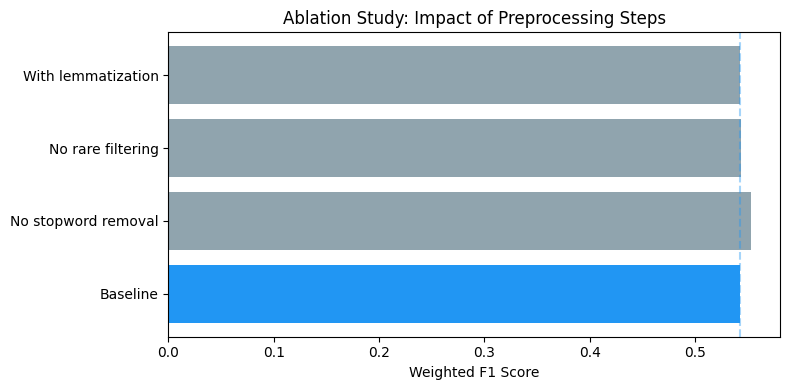

In [26]:
# Bar chart
names = list(results.keys())
scores = list(results.values())
colors = ["#2196F3" if n == "Baseline" else "#90A4AE" for n in names]

plt.figure(figsize=(8, 4))
plt.barh(names, scores, color=colors)
plt.xlabel("Weighted F1 Score")
plt.title("Ablation Study: Impact of Preprocessing Steps")
plt.axvline(x=f1_v1, color='#2196F3', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretation

**Stopword removal (Baseline vs V2):** Keeping stopwords actually improves performance (F1: 0.5428 → 0.5529, +1%). This is the most impactful finding of this study. It makes sense linguistically: function words carry genre information in song lyrics. Hip-Hop relies heavily on first-person pronouns ("I", "my", "me"), reflecting its self-referential style, while Folk and Country tend to use more third-person narration ("he", "she", "they"). Removing these words erases a useful signal for the classifier.

**Rare word filtering (Baseline vs V3):** Removing or keeping rare words has almost no effect (F1: 0.5428 vs 0.5433). This suggests that TF-IDF already handles rare words well on its own — it naturally assigns low weight to very infrequent terms. Genre-specific vocabulary like "blasphemy" (Metal) or "prairie" (Country) appears rarely in the full dataset, but TF-IDF's inverse document frequency already captures their discriminative power.

**Lemmatization (Baseline vs V4):** Adding lemmatization slightly hurts performance (F1: 0.5428 → 0.5424). The difference is small, but it suggests that morphological variation carries a small amount of genre signal. For example, Hip-Hop's use of progressive forms ("runnin'", "hustlin'") and Country's preference for past tense ("loved", "walked") are collapsed into the same base form after lemmatization, losing that distinction.

**Overall:** The most impactful preprocessing choice is stopword removal — and surprisingly, it hurts rather than helps. This tells us that in song lyrics, even "unimportant" words carry information about the genre. The other two steps (rare filtering, lemmatization) have negligible impact, which means the genre signal is mostly in the common, content-bearing vocabulary.